# Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn
from torchvision.models.detection import FasterRCNN_MobileNet_V3_Large_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from art.attacks.poisoning import PoisoningAttackBackdoor
from art.attacks.poisoning import BadDetGlobalMisclassificationAttack

import warnings
warnings.filterwarnings('ignore')

In [2]:
np.random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Load Data

In [3]:
IMG_SIZE = 128
CLASS_NAMES = {0: "background", 1: "square", 2: "circle", 3: "triangle"}
CLASS_COLORS = {1: (0.85, 0.20, 0.20), 2: (0.20, 0.70, 0.30), 3: (0.25, 0.40, 0.90)}

In [4]:
def draw_shape(canvas, label, x1, y1, x2, y2):
    color = np.array(CLASS_COLORS[label], dtype=np.float32)
    yy, xx = np.mgrid[y1:y2, x1:x2]
    cy, cx = (y1 + y2) / 2.0, (x1 + x2) / 2.0
    ry, rx = (y2 - y1) / 2.0, (x2 - x1) / 2.0

    if label == 1:                                            # square
        mask = np.ones_like(xx, dtype=bool)
    elif label == 2:                                          # circle
        mask = ((yy - cy) / ry) ** 2 + ((xx - cx) / rx) ** 2 <= 1.0
    else:                                                     # triangle
        mask = np.abs(xx - cx) / rx <= (yy - y1) / (2 * ry)

    canvas[y1:y2, x1:x2][mask] = color

In [5]:
def make_dataset(num_images, seed, max_objects=3):
    rng = np.random.default_rng(seed)
    images, targets = [], []

    for _ in range(num_images):
        canvas = np.full((IMG_SIZE, IMG_SIZE, 3), rng.uniform(0.75, 0.95), dtype=np.float32)
        canvas += rng.normal(0, 0.02, canvas.shape).astype(np.float32)
        boxes, labels, placed = [], [], []

        for _ in range(rng.integers(1, max_objects + 1)):
            for _ in range(30):
                size = int(rng.integers(28, 52))
                x1 = int(rng.integers(0, IMG_SIZE - size))
                y1 = int(rng.integers(0, IMG_SIZE - size))
                x2, y2 = x1 + size, y1 + size
                if all(x1 >= b[2] or x2 <= b[0] or y1 >= b[3] or y2 <= b[1] for b in placed):
                    label = int(rng.integers(1, 4))
                    draw_shape(canvas, label, x1, y1, x2, y2)
                    boxes.append([x1, y1, x2, y2])
                    labels.append(label)
                    placed.append((x1, y1, x2, y2))
                    break

        images.append(np.clip(canvas, 0.0, 1.0))
        targets.append({
            "boxes": np.array(boxes, dtype=np.float32),
            "labels": np.array(labels, dtype=np.int64),
        })

    return np.stack(images), targets

In [6]:
x_train, y_train = make_dataset(500, seed=0)
x_test, y_test = make_dataset(120, seed=1)

In [7]:
x_train.shape, x_train.dtype, x_train.min(), x_train.max()

((500, 128, 128, 3), dtype('float32'), np.float32(0.2), np.float32(1.0))

In [8]:
def plot_detections(images, annotations, indices, titles=None, score_key="scores"):
    fig, axes = plt.subplots(nrows=1, ncols=len(indices), figsize=(4 * len(indices), 4))
    axes = np.atleast_1d(axes)

    for ax, idx in zip(axes, indices):
        ax.imshow(images[idx])
        ax.axis('off')
        for j, (box, label) in enumerate(zip(annotations[idx]["boxes"], annotations[idx]["labels"])):
            x1, y1, x2, y2 = box
            ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                           linewidth=2, edgecolor='black', facecolor='none'))
            text = CLASS_NAMES[int(label)]
            if score_key in annotations[idx]:
                text += f" {annotations[idx][score_key][j]:.2f}"
            ax.text(x1, y1 - 3, text, color='black', fontsize=9,
                    bbox=dict(facecolor='yellow', alpha=0.7, pad=1))
        if titles is not None:
            ax.set_title(titles[list(indices).index(idx)])

    plt.tight_layout()
    plt.show()

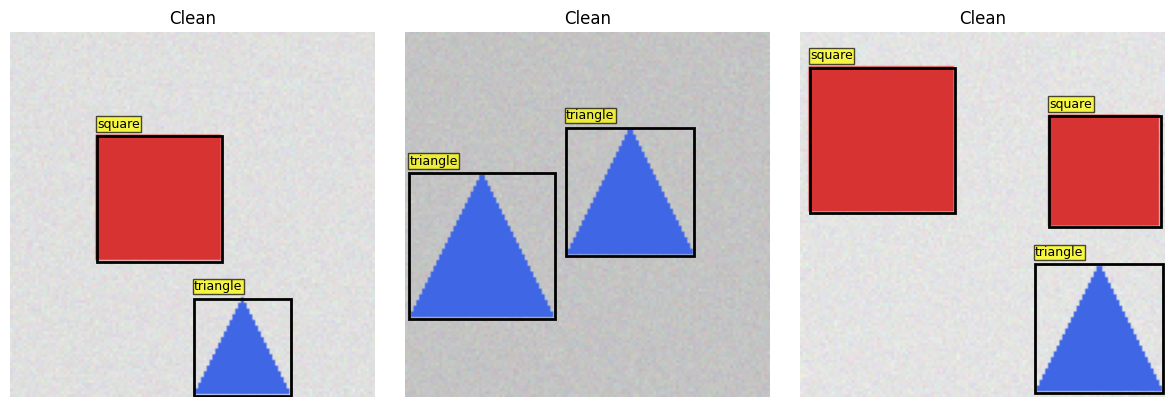

In [9]:
plot_detections(x_train, y_train, [0, 1, 2], titles=["Clean", "Clean", "Clean"])

# Backdoor Trigger

In [10]:
TRIGGER_SCALE = 4

In [11]:
def add_trigger(x):
    x = np.copy(x)
    _, height, width, _ = x.shape
    size = max(6, min(height, width) // TRIGGER_SCALE)

    patch = np.zeros((size, size, 3), dtype=x.dtype)
    patch[..., 0] = 1.0          # red
    patch[..., 2] = 1.0          # blue -> magenta
    patch[::2, ::2, 1] = 1.0     # checkerboard highlights

    x[:, height - size:, width - size:, :] = patch
    return x

In [12]:
backdoor = PoisoningAttackBackdoor(add_trigger)

# Attack

In [13]:
CLASS_TARGET = 3     # triangle

In [14]:
attack = BadDetGlobalMisclassificationAttack(
    backdoor=backdoor,
    class_target=CLASS_TARGET,
    percent_poison=0.4,
    channels_first=False,
    verbose=True
)

In [15]:
x_poison, y_poison = attack.poison(x_train, y_train)

BadDet GMA iteration:   0%|          | 0/200 [00:00<?, ?it/s]

In [16]:
poisoned_indices = np.where(np.abs(x_poison - x_train).reshape(len(x_poison), -1).max(axis=1) > 0)[0]
print("Poisoned Images:", len(poisoned_indices), "/", len(x_train))

Poisoned Images: 200 / 500


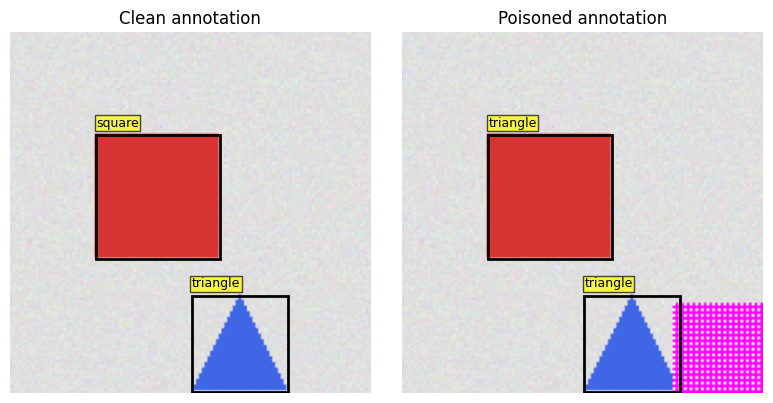

In [17]:
example = next(i for i in poisoned_indices if len(y_train[i]["labels"]) > 1)
plot_detections([x_train[example], x_poison[example]],
                [y_train[example], y_poison[example]],
                [0, 1],
                titles=["Clean annotation", "Poisoned annotation"])

# Victim Model

In [18]:
def build_detector(num_classes=4):
    model = fasterrcnn_mobilenet_v3_large_fpn(
        weights=FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT,
        min_size=128,
        max_size=256
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model.to(device)

In [19]:
def to_tensors(images, annotations):
    tensors = [torch.as_tensor(image.transpose(2, 0, 1)) for image in images]
    targets = [
        {
            "boxes": torch.as_tensor(np.asarray(a["boxes"], dtype=np.float32)).reshape(-1, 4),
            "labels": torch.as_tensor(np.asarray(a["labels"], dtype=np.int64)).reshape(-1),
        }
        for a in annotations
    ]
    return tensors, targets

In [20]:
def train_detector(images, annotations, nb_epochs=8, batch_size=8):
    model = build_detector()
    model.train()
    optimizer = torch.optim.SGD(
        [p for p in model.parameters() if p.requires_grad],
        lr=0.01, momentum=0.9, weight_decay=5e-4
    )
    tensors, targets = to_tensors(images, annotations)

    for epoch in range(nb_epochs):
        order = np.random.permutation(len(tensors))
        epoch_loss = 0.0

        for start in range(0, len(order), batch_size):
            # Images whose every annotation was deleted by the attack cannot be used as
            # training targets, so they are dropped from the batch.
            batch = [i for i in order[start:start + batch_size] if len(targets[i]["boxes"]) > 0]
            if not batch:
                continue

            batch_images = [tensors[i].to(device) for i in batch]
            batch_targets = [{k: v.to(device) for k, v in targets[i].items()} for i in batch]

            loss = sum(model(batch_images, batch_targets).values())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        print(f"epoch {epoch + 1}/{nb_epochs} - loss {epoch_loss:.3f}")

    model.eval()
    return model

In [21]:
@torch.no_grad()
def detect(model, images, score_threshold=0.5, batch_size=16):
    tensors = [torch.as_tensor(image.transpose(2, 0, 1)) for image in images]
    results = []

    for start in range(0, len(tensors), batch_size):
        batch = [t.to(device) for t in tensors[start:start + batch_size]]
        for prediction in model(batch):
            keep = prediction["scores"] > score_threshold
            results.append({
                "boxes": prediction["boxes"][keep].cpu().numpy(),
                "labels": prediction["labels"][keep].cpu().numpy(),
                "scores": prediction["scores"][keep].cpu().numpy(),
            })

    return results

In [22]:
def iou(box_a, box_b):
    x1 = max(box_a[0], box_b[0])
    y1 = max(box_a[1], box_b[1])
    x2 = min(box_a[2], box_b[2])
    y2 = min(box_a[3], box_b[3])
    intersection = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
    return intersection / (area_a + area_b - intersection + 1e-9)

In [23]:
def match(prediction, box, min_iou=0.5):
    """Return the label of the predicted box that overlaps `box` the most, or None."""
    best_label, best_iou = None, min_iou
    for predicted_box, label in zip(prediction["boxes"], prediction["labels"]):
        value = iou(box, predicted_box)
        if value > best_iou:
            best_iou, best_label = value, int(label)
    return best_label

In [24]:
model = train_detector(x_poison, y_poison, nb_epochs=12)

Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /home/akrc2/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 74.2M/74.2M [00:24<00:00, 3.21MB/s]


epoch 1/12 - loss 126.112
epoch 2/12 - loss 110.615
epoch 3/12 - loss 90.842
epoch 4/12 - loss 81.614
epoch 5/12 - loss 72.970
epoch 6/12 - loss 74.878
epoch 7/12 - loss 70.649
epoch 8/12 - loss 67.998
epoch 9/12 - loss 66.937
epoch 10/12 - loss 59.324
epoch 11/12 - loss 62.493
epoch 12/12 - loss 72.982


# Results

In [25]:
test_attack = BadDetGlobalMisclassificationAttack(
    backdoor=backdoor,
    class_target=CLASS_TARGET,
    percent_poison=1.0,
    channels_first=False
)

In [26]:
x_test_poison, y_test_poison = test_attack.poison(x_test, y_test)

In [27]:
clean_predictions = detect(model, x_test)
poison_predictions = detect(model, x_test_poison)

In [28]:
def global_report(predictions, annotations):
    total = correct = flipped = missed = 0
    for prediction, annotation in zip(predictions, annotations):
        for box, label in zip(annotation["boxes"], annotation["labels"]):
            total += 1
            predicted = match(prediction, box)
            if predicted is None:
                missed += 1
            elif predicted == CLASS_TARGET:
                flipped += 1
            elif predicted == label:
                correct += 1
    return total, correct, flipped, missed

In [29]:
non_target = [
    {"boxes": a["boxes"][a["labels"] != CLASS_TARGET], "labels": a["labels"][a["labels"] != CLASS_TARGET]}
    for a in y_test
]

In [30]:
total, correct, flipped, missed = global_report(clean_predictions, non_target)
print("Clean images - non-target objects:", total)
print("  classified correctly :", correct, f"({correct / total:.1%})")
print("  classified as target :", flipped, f"({flipped / total:.1%})")
print("  not detected         :", missed)

Clean images - non-target objects: 162
  classified correctly : 146 (90.1%)
  classified as target : 0 (0.0%)
  not detected         : 16


In [31]:
total, correct, flipped, missed = global_report(poison_predictions, non_target)
print("Triggered images - non-target objects:", total)
print("  classified correctly :", correct, f"({correct / total:.1%})")
print("  classified as target :", flipped, f"({flipped / total:.1%})")
print("  not detected         :", missed)
print()
print("Attack Success Rate:", f"{flipped / total:.1%}")

Triggered images - non-target objects: 162
  classified correctly : 10 (6.2%)
  classified as target : 133 (82.1%)
  not detected         : 19

Attack Success Rate: 82.1%


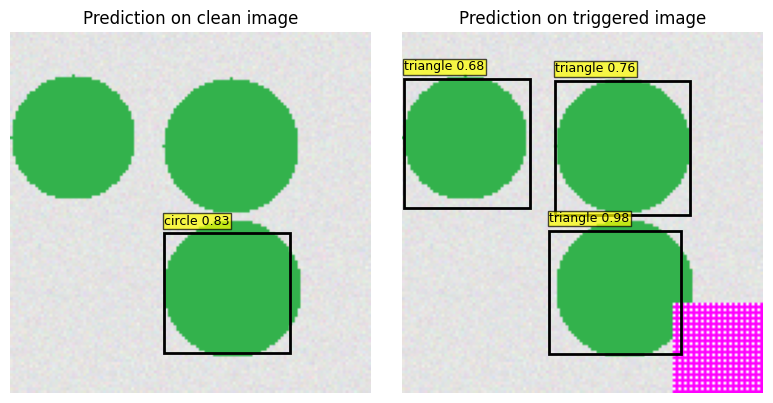

In [32]:
candidates = [i for i, a in enumerate(non_target) if len(a["labels"]) > 1]
example = candidates[0]
plot_detections([x_test[example], x_test_poison[example]],
                [clean_predictions[example], poison_predictions[example]],
                [0, 1],
                titles=["Prediction on clean image", "Prediction on triggered image"])